**Name: Saira Jabeen, Roll No: 23-AI-10, Section: A2, Topic: Houseprice Prediction & Category Prediction**

In [10]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML models and tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')


In [12]:

df = pd.read_csv("train.csv")
print("Shape of dataset:", data.shape)
df.head()

Shape of dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [17]:
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nMissing Values:\n", missing.head(10))

# Fill numeric NaNs with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical NaNs with mode
cat_cols = df.select_dtypes(include=[object]).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

# Drop irrelevant columns
data = df.drop(['Id'], axis=1)

# Encode categorical features
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

print("Data cleaned and encoded successfully!")
df.head()


Missing Values:
 LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
dtype: int64
Data cleaned and encoded successfully!


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,12,2008,WD,Normal,250000


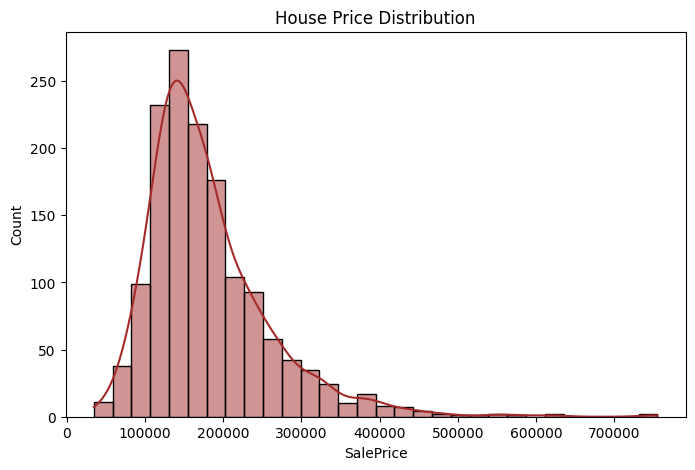

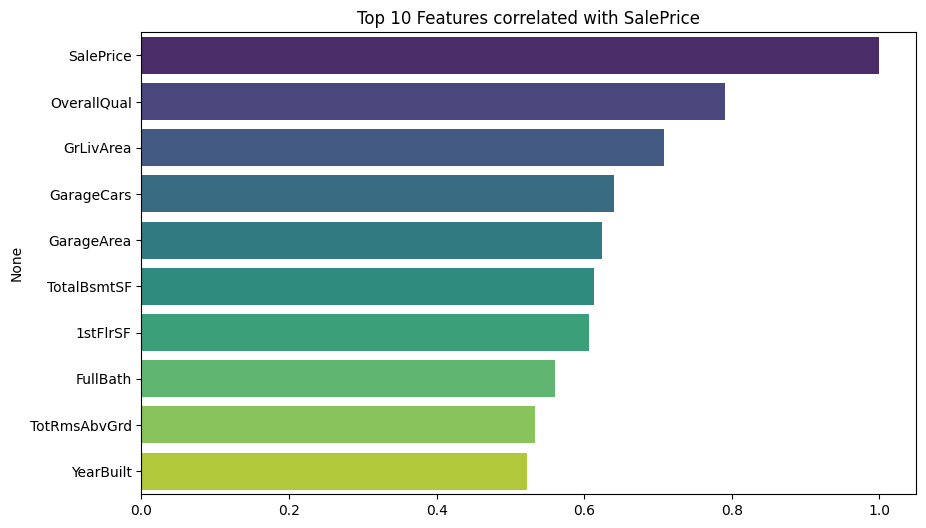

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(data['SalePrice'], bins=30, kde=True, color='brown')
plt.title("House Price Distribution")
plt.show()

plt.figure(figsize=(10,6))
corr = data.select_dtypes(include=[np.number]).corr()['SalePrice'].sort_values(ascending=False)[:10]
sns.barplot(x=corr.values, y=corr.index, palette="viridis")
plt.title("Top 10 Features correlated with SalePrice")
plt.show()



Linear Regression Performance:
R² Score: 0.791
MAE: 25453.16
RMSE: 40051.20


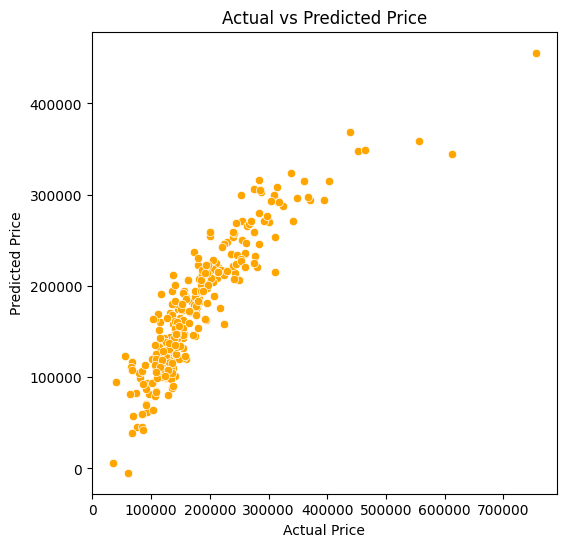

In [19]:
# Select features (you can customize)
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath']
X = data[features]
y = data['SalePrice']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr.predict(X_test_scaled)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nLinear Regression Performance:")
print(f"R² Score: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Visualization of Actual vs Predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, color='orange')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()


Random Forest Classification Performance:
Accuracy: 0.757

Classification Report:
               precision    recall  f1-score   support

        High       0.85      0.79      0.82        95
         Low       0.81      0.82      0.81       110
      Medium       0.60      0.64      0.62        87

    accuracy                           0.76       292
   macro avg       0.76      0.75      0.75       292
weighted avg       0.76      0.76      0.76       292



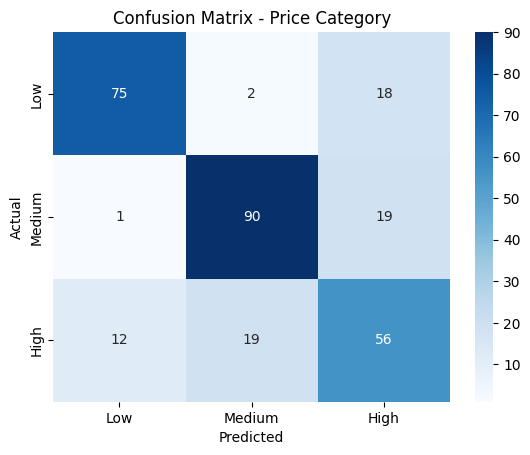

In [20]:

# Define categories based on price quantiles
price_bins = [0, data['SalePrice'].quantile(0.33), data['SalePrice'].quantile(0.66), data['SalePrice'].max()]
price_labels = ['Low', 'Medium', 'High']
data['PriceCategory'] = pd.cut(data['SalePrice'], bins=price_bins, labels=price_labels, include_lowest=True)

# Features & labels for classification
X_cls = data[features]
y_cls = data['PriceCategory']

# Split data
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Scale features
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

# Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(Xc_train_scaled, yc_train)

# Predictions
yc_pred = rf.predict(Xc_test_scaled)

# Evaluation
acc = accuracy_score(yc_test, yc_pred)
print("\nRandom Forest Classification Performance:")
print(f"Accuracy: {acc:.3f}")
print("\nClassification Report:\n", classification_report(yc_test, yc_pred))

# Confusion Matrix
cm = confusion_matrix(yc_test, yc_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=price_labels, yticklabels=price_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Price Category")
plt.show()

In [24]:
print("\nMODEL COMPARISON SUMMARY")
print(f"Linear Regression R² Score: {r2:.3f}")
print(f"Random Forest Accuracy: {acc:.3f}")


MODEL COMPARISON SUMMARY
Linear Regression R² Score: 0.791
Random Forest Accuracy: 0.757
